# Topology PoC — Hypothesis Analysis

**Гипотеза:** структурные метрики графа топологии коррелируют с accuracy MAS.

Запусти `python scripts/run_poc.py` перед открытием ноутбука.

## Agent module test — проверка API ключа и пайплайна

In [1]:
# import sys, os
# from pathlib import Path

# ROOT = Path("..").resolve()
# if str(ROOT) not in sys.path:
#     sys.path.insert(0, str(ROOT))

# from mas.agent import Agent, AgentConfig
# from mas.prompts import parse_answer

# TASK = "Janet's ducks lay 16 eggs per day. She eats 3 for breakfast and bakes 4 into muffins. She sells the rest at $2 per egg. How much does she make per day?"
# GT   = 18   # (16 - 3 - 4) * 2 = 18

# # ── 1. Stub (без API) ───────────────────────────────────────────────────────
# stub_agent = Agent(AgentConfig("A0", "solver", stub=True))
# stub_out   = stub_agent.run(TASK, [])
# print("=== STUB ===")
# print(stub_out)
# print()

# # ── 2. Real API ────────────────────────────────────────────────────────────
# print("=== REAL API ===")
# print(f"OPENAI_API_KEY set: {bool(os.environ.get('OPENAI_API_KEY'))}")

# real_agent = Agent(AgentConfig("A0", "solver", model="gpt-3.5-turbo", stub=False))
# real_out   = real_agent.run(TASK, [])
# pred       = parse_answer(real_out)

# print(real_out)
# print()
# print(f"Parsed:  {pred}")
# print(f"GT:      {GT}")
# print(f"Correct: {pred == GT}")

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})

## 1. Загрузка результатов

In [3]:
results_dir  = Path("../results")
results_path = results_dir / "results.json"
index_path   = results_dir / "runs_index.json"

# ── показать историю прогонов ──────────────────────────────────────────
if index_path.exists():
    idx = json.loads(index_path.read_text())
    idx_df = pd.DataFrame(idx)[[
        'run_id','timestamp','model','n_questions','stub',
        'n_topologies','duration_sec','mean_accuracy'
    ]]
    print(f"Runs in index: {len(idx_df)}")
    display(idx_df)
else:
    print("runs_index.json not found — run scripts/run_poc.py first")

# ── загрузить последний прогон ────────────────────────────────────────
MOCK = [
    {"topology": "chain",  "accuracy": 0.55, "duration_sec": 5.0,
     "metrics": {"diameter": 2.5, "avg_degree": 1.0, "structural_entropy": 1.50, "spectral_gap": 0.29, "task_centrality": 0.50}},
    {"topology": "star",   "accuracy": 0.60, "duration_sec": 5.0,
     "metrics": {"diameter": 2.0, "avg_degree": 1.0, "structural_entropy": 1.58, "spectral_gap": 0.75, "task_centrality": 1.00}},
    {"topology": "full",   "accuracy": 0.70, "duration_sec": 5.0,
     "metrics": {"diameter": 1.0, "avg_degree": 3.0, "structural_entropy": 2.00, "spectral_gap": 1.00, "task_centrality": 0.22}},
    {"topology": "random", "accuracy": 0.50, "duration_sec": 5.0,
     "metrics": {"diameter": 1.7, "avg_degree": 1.3, "structural_entropy": 1.42, "spectral_gap": 0.55, "task_centrality": 0.35}},
]

if results_path.exists():
    raw  = json.loads(results_path.read_text())
    # поддержка нового формата {meta, results} и старого формата [list]
    data = raw['results'] if isinstance(raw, dict) else raw
    meta = raw.get('meta', {}) if isinstance(raw, dict) else {}
    if meta:
        print(f"\nLoaded run {meta.get('run_id')}  "
              f"model={meta.get('model')}  "
              f"n_questions={meta.get('n_questions')}  "
              f"total={meta.get('duration_sec')}s")
else:
    data = MOCK
    meta = {}
    print("⚠️  results.json not found — using mock data")

df = pd.DataFrame([
    {"topology": r["topology"],
     "accuracy": r["accuracy"],
     "duration_sec": r.get("duration_sec", 0),
     **r["metrics"]}
    for r in data
])
df


Runs in index: 16


,run_id,timestamp,model,n_questions,stub,n_topologies,duration_sec,mean_accuracy
0,20260523_131942,2026-05-23T13:19:42.968451+00:00,gpt-3.5-turbo,3,True,4,0.02,0.0000
1,20260523_164750,2026-05-23T16:47:50.793068+00:00,gpt-3.5-turbo,1,False,23,198.75,0.0000
2,20260523_172627,2026-05-23T17:26:27.636940+00:00,gpt-5-nano-2025-08-07,5,False,24,2529.46,1.0000
3,20260523_165321,2026-05-23T16:53:21.062693+00:00,gpt-5.4-mini-2026-03-17,50,False,23,7373.68,0.9574
4,20260523_194652,2026-05-23T19:46:52.471842+00:00,gpt-4o-mini-2024-07-18,10,False,5,591.86,0.9000
5,20260523_195904,2026-05-23T19:59:04.466639+00:00,gpt-3.5-turbo,2,True,23,0.05,0.0000
6,20260523_200834,2026-05-23T20:08:34.095514+00:00,gpt-3.5-turbo,3,True,4,0.02,0.0000
7,20260523_200846,2026-05-23T20:08:46.650353+00:00,gpt-3.5-turbo,3,True,4,0.01,0.0000
8,20260523_201126,2026-05-23T20:11:26.722925+00:00,gpt-3.5-turbo,3,True,23,0.05,0.0000
9,20260523_201819,2026-05-23T20:18:19.193862+00:00,gpt-3.5-turbo,3,True,23,0.05,0.0000



Loaded run 20260524_050322  model=gpt-4o-mini-2024-07-18  n_questions=20  total=16432.79s


,topology,accuracy,duration_sec,diameter,avg_degree,structural_entropy,spectral_gap,task_centrality
0,chain_3,0.45,487.84,1.666667,0.750000,1.918296,0.500000,0.0
1,star_3,0.45,815.93,1.400000,1.200000,2.292481,1.000000,0.0
2,fc_3,0.45,495.48,1.000000,1.500000,2.000000,1.333333,0.0
3,hierarchical_3,0.40,1079.16,1.600000,1.166667,2.467720,0.646447,0.0
4,two_layer_ensemble_3,0.45,911.46,1.300000,1.400000,2.235926,1.000000,0.0
5,chain_5,0.45,931.47,2.333333,0.833333,2.521928,0.190983,0.0
6,star_5,0.40,1477.05,1.523810,1.428571,2.660964,1.000000,0.0
7,fc_5,0.40,911.71,1.000000,2.500000,2.584963,1.200000,0.0
8,hierarchical_5,0.50,1495.79,1.642857,1.375000,2.772185,0.711325,0.0
9,two_layer_ensemble_5,0.40,1211.89,1.476190,1.571429,2.594907,1.000000,0.0


## 2. Scatter plots: метрика vs accuracy

Каждый граф — одна точка. Если гипотеза верна, хотя бы один subplot покажет монотонный тренд.

In [4]:
df

,topology,accuracy,duration_sec,diameter,avg_degree,structural_entropy,spectral_gap,task_centrality
0,chain_3,0.45,487.84,1.666667,0.750000,1.918296,0.500000,0.0
1,star_3,0.45,815.93,1.400000,1.200000,2.292481,1.000000,0.0
2,fc_3,0.45,495.48,1.000000,1.500000,2.000000,1.333333,0.0
3,hierarchical_3,0.40,1079.16,1.600000,1.166667,2.467720,0.646447,0.0
4,two_layer_ensemble_3,0.45,911.46,1.300000,1.400000,2.235926,1.000000,0.0
5,chain_5,0.45,931.47,2.333333,0.833333,2.521928,0.190983,0.0
6,star_5,0.40,1477.05,1.523810,1.428571,2.660964,1.000000,0.0
7,fc_5,0.40,911.71,1.000000,2.500000,2.584963,1.200000,0.0
8,hierarchical_5,0.50,1495.79,1.642857,1.375000,2.772185,0.711325,0.0
9,two_layer_ensemble_5,0.40,1211.89,1.476190,1.571429,2.594907,1.000000,0.0


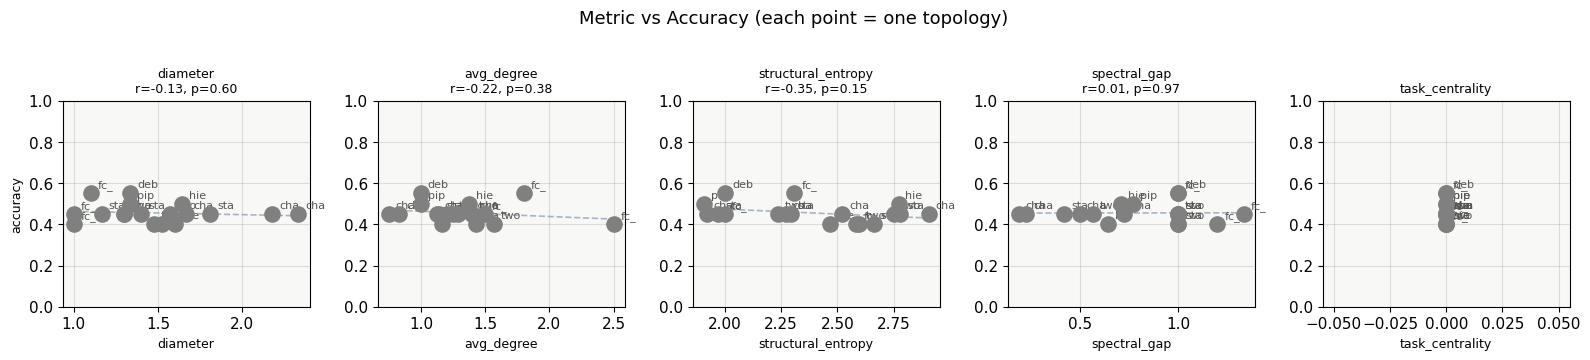

Сохранено → results/scatter_plots.png


In [6]:
METRIC_COLS = ["diameter", "avg_degree", "structural_entropy", "spectral_gap", "task_centrality"]
COLORS = {"chain": "#3B82F6", "star": "#10B981", "full": "#F59E0B", "random": "#EF4444"}

fig, axes = plt.subplots(1, len(METRIC_COLS), figsize=(16, 3.5))
fig.suptitle("Metric vs Accuracy (each point = one topology)", fontsize=13, y=1.02)

for ax, metric in zip(axes, METRIC_COLS):
    x = df[metric].values
    y = df["accuracy"].values

    for _, row in df.iterrows():
        ax.scatter(row[metric], row["accuracy"],
                   color=COLORS.get(row["topology"], "gray"),
                   s=120, zorder=5, label=row["topology"])
        ax.annotate(row["topology"][:3],
                    (row[metric], row["accuracy"]),
                    textcoords="offset points", xytext=(5, 4),
                    fontsize=8, color="#555")

    # линия тренда
    if len(x) > 2 and np.std(x) > 0:
        m, b = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 50)
        ax.plot(xline, m * xline + b, "--", color="#94a3b8", lw=1.2, alpha=0.8)
        r, p = stats.pearsonr(x, y)
        ax.set_title(f"{metric}\nr={r:.2f}, p={p:.2f}", fontsize=9)
    else:
        ax.set_title(metric, fontsize=9)

    ax.set_xlabel(metric, fontsize=9)
    ax.set_ylabel("accuracy" if metric == METRIC_COLS[0] else "", fontsize=9)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../results/scatter_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено → results/scatter_plots.png")

## 3. Корреляции: Spearman, Kendall τ, Pearson

In [7]:
rows = []
for metric in METRIC_COLS:
    x = df[metric].values
    y = df["accuracy"].values
    if np.std(x) > 0:
        rho, sp  = stats.spearmanr(x, y)
        tau, tp  = stats.kendalltau(x, y)
        r,   rp  = stats.pearsonr(x, y)
    else:
        rho, sp, tau, tp, r, rp = 0.0, 1.0, 0.0, 1.0, 0.0, 1.0
    rows.append({
        "metric":      metric,
        "spearman_r":  round(rho, 3),
        "spearman_p":  round(sp,  3),
        "kendall_tau": round(tau, 3),
        "kendall_p":   round(tp,  3),
        "pearson_r":   round(r,   3),
        "pearson_p":   round(rp,  3),
    })

corr_df = pd.DataFrame(rows).sort_values("spearman_r", key=abs, ascending=False)

def highlight(val):
    if isinstance(val, float) and abs(val) > 0.7:
        return "background-color: #d1fae5; font-weight: bold"
    if isinstance(val, float) and abs(val) > 0.4:
        return "background-color: #fef3c7"
    return ""

corr_df.style.map(highlight, subset=["spearman_r", "kendall_tau", "pearson_r"])

,metric,spearman_r,spearman_p,kendall_tau,kendall_p,pearson_r,pearson_p
1,avg_degree,-0.306000,0.216000,-0.252000,0.190000,-0.221000,0.379000
2,structural_entropy,-0.304000,0.220000,-0.235000,0.221000,-0.352000,0.151000
0,diameter,-0.081000,0.749000,-0.065000,0.735000,-0.131000,0.603000
3,spectral_gap,-0.010000,0.968000,0.008000,0.966000,0.010000,0.969000
4,task_centrality,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000


## 4. Mutual Information: нелинейная зависимость метрики с accuracy

In [8]:
df

,topology,accuracy,duration_sec,diameter,avg_degree,structural_entropy,spectral_gap,task_centrality
0,chain_3,0.45,487.84,1.666667,0.750000,1.918296,0.500000,0.0
1,star_3,0.45,815.93,1.400000,1.200000,2.292481,1.000000,0.0
2,fc_3,0.45,495.48,1.000000,1.500000,2.000000,1.333333,0.0
3,hierarchical_3,0.40,1079.16,1.600000,1.166667,2.467720,0.646447,0.0
4,two_layer_ensemble_3,0.45,911.46,1.300000,1.400000,2.235926,1.000000,0.0
5,chain_5,0.45,931.47,2.333333,0.833333,2.521928,0.190983,0.0
6,star_5,0.40,1477.05,1.523810,1.428571,2.660964,1.000000,0.0
7,fc_5,0.40,911.71,1.000000,2.500000,2.584963,1.200000,0.0
8,hierarchical_5,0.50,1495.79,1.642857,1.375000,2.772185,0.711325,0.0
9,two_layer_ensemble_5,0.40,1211.89,1.476190,1.571429,2.594907,1.000000,0.0


In [9]:
x

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0.])

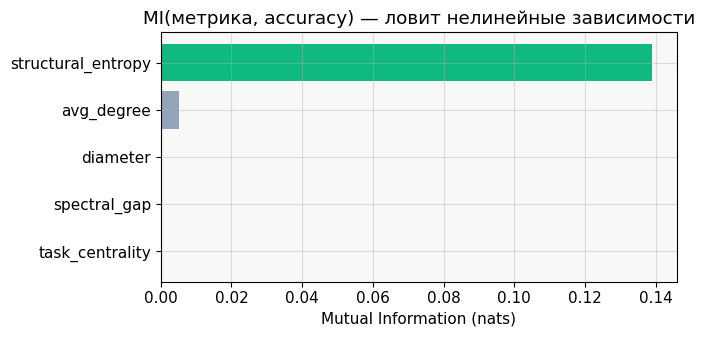

,metric,mutual_info
2,structural_entropy,0.1391
1,avg_degree,0.0053
0,diameter,0.0000
3,spectral_gap,0.0000
4,task_centrality,0.0000


In [10]:
from sklearn.feature_selection import mutual_info_regression

mi_rows = []
for metric in METRIC_COLS:
    x = df[[metric]].values
    y = df["accuracy"].values
    mi = mutual_info_regression(x, y, random_state=42)[0]# if np.std(x) > 0 else 0.0
    mi_rows.append({"metric": metric, "mutual_info": round(mi, 4)})

mi_df = pd.DataFrame(mi_rows).sort_values("mutual_info", ascending=False)

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ["#10b981" if v >= 0.05 else "#94a3b8" for v in mi_df["mutual_info"]]
ax.barh(mi_df["metric"], mi_df["mutual_info"], color=colors)
ax.set_xlabel("Mutual Information (nats)")
ax.set_title("MI(метрика, accuracy) — ловит нелинейные зависимости")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../results/mutual_info.png", dpi=120, bbox_inches="tight")
plt.show()
display(mi_df)

## 5. Top-K Accuracy: метрика как proxy для отбора топ-K топологий

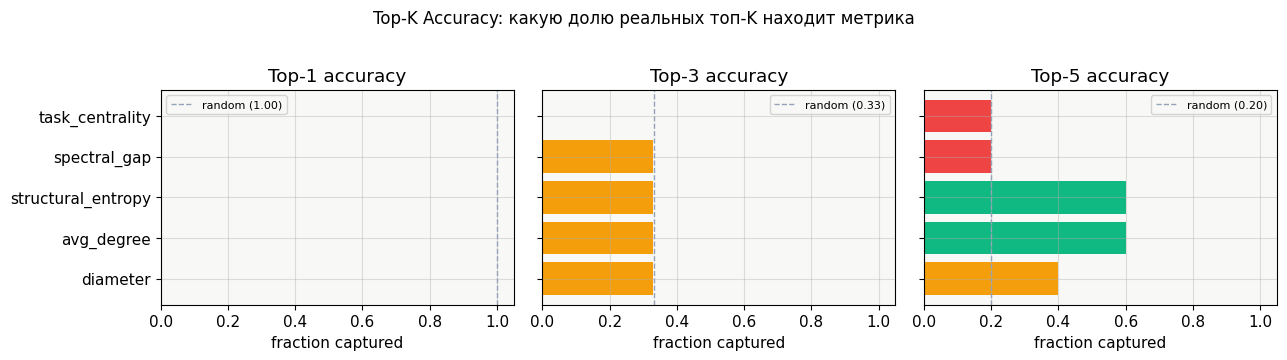

Baseline (random): {'top1': 1.0, 'top3': 0.33, 'top5': 0.2}


,metric,top1,top3,top5
0,diameter,0.0,0.33,0.4
1,avg_degree,0.0,0.33,0.6
2,structural_entropy,0.0,0.33,0.6
3,spectral_gap,0.0,0.33,0.2
4,task_centrality,0.0,0.00,0.2


In [11]:
def top_k_accuracy(df, metric, k):
    """Fraction of real top-k topologies captured by metric top-k (best direction)."""
    real_top = set(df.nlargest(k, "accuracy")["topology"])
    hi_match = len(real_top & set(df.nlargest(k, metric)["topology"]))
    lo_match = len(real_top & set(df.nsmallest(k, metric)["topology"]))
    return max(hi_match, lo_match) / k

Ks = [1, 3, 5]
topk_rows = []
for metric in METRIC_COLS:
    row = {"metric": metric}
    for k in Ks:
        row[f"top{k}"] = round(top_k_accuracy(df, metric, k), 2)
    topk_rows.append(row)

topk_df = pd.DataFrame(topk_rows).sort_values("top3", ascending=False)

fig, axes = plt.subplots(1, len(Ks), figsize=(13, 3.5), sharey=True)
for ax, k in zip(axes, Ks):
    col = f"top{k}"
    vals = topk_df.set_index("metric")[col]
    bar_colors = ["#10b981" if v >= 0.6 else "#f59e0b" if v >= 0.3 else "#ef4444"
                  for v in vals]
    ax.barh(vals.index, vals.values, color=bar_colors)
    ax.set_xlim(0, 1.05)
    ax.axvline(1 / k, ls="--", color="#94a3b8", lw=1, label=f"random ({1/k:.2f})")
    ax.set_title(f"Top-{k} accuracy")
    ax.set_xlabel("fraction captured")
    ax.legend(fontsize=8)

plt.suptitle("Top-K Accuracy: какую долю реальных топ-K находит метрика", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("../results/topk_accuracy.png", dpi=120, bbox_inches="tight")
plt.show()

# итоговая таблица
print("Baseline (random):", {f"top{k}": round(1/k, 2) for k in Ks})
display(topk_df)

## 6. Radar chart: топологии по всем метрикам

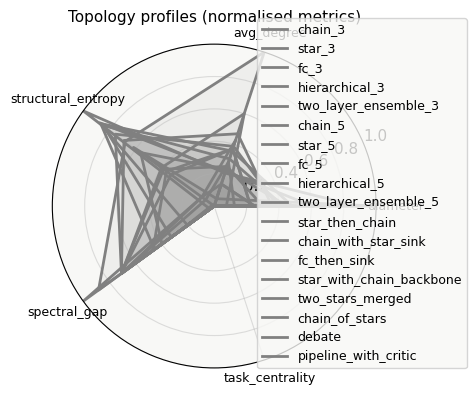

In [12]:
from matplotlib.patches import FancyArrowPatch

# нормализуем метрики в [0,1] для radar
radar_df = df[METRIC_COLS].copy()
radar_df = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min() + 1e-9)
radar_df["topology"] = df["topology"]

N = len(METRIC_COLS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))
ax.set_facecolor("#f8f8f6")

for _, row in radar_df.iterrows():
    vals = row[METRIC_COLS].tolist()
    vals += vals[:1]
    color = COLORS.get(row["topology"], "gray")
    ax.plot(angles, vals, color=color, lw=2, label=row["topology"])
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_thetagrids(np.degrees(angles[:-1]), METRIC_COLS, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("Topology profiles (normalised metrics)", pad=16, fontsize=11)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig("../results/radar.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Ранжирование: прокси vs реальность

In [15]:
# Выбираем лучшую метрику по |Spearman r|
best_metric = corr_df.iloc[0]["metric"]
rho_best = corr_df.iloc[0]["spearman_r"]
print(f"Лучшая метрика: {best_metric}  (Spearman r = {rho_best})")

rank_df = df[["topology", "accuracy", best_metric]].copy()
rank_df["rank_real"]  = rank_df["accuracy"].rank(ascending=False).astype(int)
rank_df["rank_proxy"] = rank_df[best_metric].rank(ascending=rho_best > 0).astype(int)
rank_df["rank_match"] = rank_df["rank_real"] == rank_df["rank_proxy"]

display(rank_df.sort_values("rank_real"))

top1_match = rank_df.loc[rank_df["rank_real"] == 1, "rank_match"].values[0]
print(f"\nTop-1 совпадение: {'✅' if top1_match else '❌'}")
print(f"Топ-1 по accuracy:  {rank_df.loc[rank_df['rank_real']==1,'topology'].values[0]}")
print(f"Топ-1 по {best_metric}: {rank_df.loc[rank_df['rank_proxy']==1,'topology'].values[0]}")

Лучшая метрика: avg_degree  (Spearman r = -0.306)


,topology,accuracy,avg_degree,rank_real,rank_proxy,rank_match
12,fc_then_sink,0.55,1.800000,1,2,False
16,debate,0.55,1.000000,1,15,False
8,hierarchical_5,0.50,1.375000,3,8,False
17,pipeline_with_critic,0.50,1.000000,3,15,False
4,two_layer_ensemble_3,0.45,1.400000,9,6,False
5,chain_5,0.45,0.833333,9,17,False
2,fc_3,0.45,1.500000,9,4,False
10,star_then_chain,0.45,1.142857,9,13,False
11,chain_with_star_sink,0.45,1.400000,9,6,False
1,star_3,0.45,1.200000,9,11,False



Top-1 совпадение: ❌
Топ-1 по accuracy:  fc_then_sink
Топ-1 по avg_degree: fc_5


## 8. Вывод

In [18]:
print("=== PoC Summary ===")
print(f"Топологий: {len(df)}")
print(f"Лучшая метрика: {best_metric} (|r|={abs(rho_best):.2f})")
print()

if abs(rho_best) >= 0.7:
    verdict = "✅ СИЛЬНАЯ корреляция — гипотеза подтверждена, переходим к фазе 2"
elif abs(rho_best) >= 0.3:
    verdict = "⚠️  СЛАБАЯ корреляция — сигнал есть, нужно больше топологий и задач"
else:
    verdict = "❌ НЕТ корреляции — метрики не работают в таком виде, пересматриваем"

print(verdict)
print()
print("Следующий шаг:")
print("  → Если ✅: расширить до 20+ топологий, добавить RNI-эмбеддинги")
print("  → Если ⚠️ : добавить proxy-IDS (GEMMAS), попробовать взвешенную комбинацию")
print("  → Если ❌ : проверить правильность парсинга ответов, попробовать другой датасет")

=== PoC Summary ===
Топологий: 16
Лучшая метрика: avg_degree (|r|=0.31)

⚠️  СЛАБАЯ корреляция — сигнал есть, нужно больше топологий и задач

Следующий шаг:
  → Если ✅: расширить до 20+ топологий, добавить RNI-эмбеддинги
  → Если ⚠️ : добавить proxy-IDS (GEMMAS), попробовать взвешенную комбинацию
  → Если ❌ : проверить правильность парсинга ответов, попробовать другой датасет


In [17]:
df = df.query("topology != 'fc_then_sink'").dropna()
df = df.query("topology != 'star_3'").dropna()
df

,topology,accuracy,duration_sec,diameter,avg_degree,structural_entropy,spectral_gap,task_centrality
0,chain_3,0.45,487.84,1.666667,0.750000,1.918296,0.500000,0.0
2,fc_3,0.45,495.48,1.000000,1.500000,2.000000,1.333333,0.0
3,hierarchical_3,0.40,1079.16,1.600000,1.166667,2.467720,0.646447,0.0
4,two_layer_ensemble_3,0.45,911.46,1.300000,1.400000,2.235926,1.000000,0.0
5,chain_5,0.45,931.47,2.333333,0.833333,2.521928,0.190983,0.0
6,star_5,0.40,1477.05,1.523810,1.428571,2.660964,1.000000,0.0
7,fc_5,0.40,911.71,1.000000,2.500000,2.584963,1.200000,0.0
8,hierarchical_5,0.50,1495.79,1.642857,1.375000,2.772185,0.711325,0.0
9,two_layer_ensemble_5,0.40,1211.89,1.476190,1.571429,2.594907,1.000000,0.0
10,star_then_chain,0.45,1242.28,1.809524,1.142857,2.780639,0.422650,0.0
